## 3. Classification of word problems
This module presents a classification LM, that classifies hebrew math word problems. The pre-trained module (downloaded from hugging-face library) was finetuned with labeled samples, and then tested. The data was gathered from open source, and then augmented as shown below.

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

/Users/erannovak/miniconda3/envs/openUNLP/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

### Load model and tokenizer

For this task the model tokenizer was used. This tokenizer sometimes 'breaks' hebrew letters due to bite-level Encoding (hebrew letters have 2 byte representation). As a result the tokens may sometimes look like these two samples from the tokenization test below (breaking the letter 'ס').

ID: 1660 | Hebrew:  מהמ�
ID: 1794 | Hebrew: �פר

In [3]:

model_name = "Norod78/distilgpt2-base-pretrained-he"
tokenizer = AutoTokenizer.from_pretrained(model_name)

vocab = tokenizer.get_vocab()

print(f"vocab size {len(vocab)} tokens")


vocab size 50257 tokens


In [4]:
def inspect_tokenization(text, tokenizer):
    token_ids = tokenizer.encode(text)
    for token_id in token_ids:
        readable_token = tokenizer.decode([token_id])
        print(f"ID: {token_id} | Hebrew: {readable_token}")


In [5]:
inspect_tokenization("""א. נתונים שני מספרים. אם נוסיף 3 למספר הראשון, התוצאה תהיה גדולה פי 3 מהמספר השני:
אם נוסיף 2 למספר השני, התוצאה תהיה חצי מהמספר הראשון. מהם שני המספרים?
""", tokenizer)

ID: 650 | Hebrew: א
ID: 18 | Hebrew: .
ID: 3835 | Hebrew:  נתונים
ID: 1165 | Hebrew:  שני
ID: 8766 | Hebrew:  מספרים
ID: 18 | Hebrew: .
ID: 568 | Hebrew:  אם
ID: 20837 | Hebrew:  נוסיף
ID: 765 | Hebrew:  3
ID: 9098 | Hebrew:  למספר
ID: 1268 | Hebrew:  הראשון
ID: 16 | Hebrew: ,
ID: 5522 | Hebrew:  התוצאה
ID: 2196 | Hebrew:  תהיה
ID: 2493 | Hebrew:  גדולה
ID: 1179 | Hebrew:  פי
ID: 765 | Hebrew:  3
ID: 1660 | Hebrew:  מהמ�
ID: 1794 | Hebrew: �פר
ID: 1468 | Hebrew:  השני
ID: 30 | Hebrew: :
ID: 203 | Hebrew: 

ID: 1452 | Hebrew: אם
ID: 20837 | Hebrew:  נוסיף
ID: 419 | Hebrew:  2
ID: 9098 | Hebrew:  למספר
ID: 1468 | Hebrew:  השני
ID: 16 | Hebrew: ,
ID: 5522 | Hebrew:  התוצאה
ID: 2196 | Hebrew:  תהיה
ID: 2729 | Hebrew:  חצי
ID: 1660 | Hebrew:  מהמ�
ID: 1794 | Hebrew: �פר
ID: 1268 | Hebrew:  הראשון
ID: 18 | Hebrew: .
ID: 1771 | Hebrew:  מהם
ID: 1165 | Hebrew:  שני
ID: 26905 | Hebrew:  המספרים
ID: 35 | Hebrew: ?
ID: 203 | Hebrew: 



Loading the model.

In [6]:
he_model = AutoModelForCausalLM.from_pretrained(model_name)

checking text genetation

In [7]:
def generate_text(prompt, he_model, tokenizer):
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    he_model.config.pad_token_id = he_model.config.eos_token_id

    input_ids = tokenizer.encode(prompt, return_tensors="pt")

    # generate text
    output = he_model.generate(
        input_ids=input_ids,
        max_new_tokens=20,
        do_sample=True,
        top_k=50,
        top_p=0.95,
        temperature=0.7,
        no_repeat_ngram_size=2,
    )
    generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
    return generated_text


In [8]:
generate_text(" בכיתה שלושים תלמידים, מהם 15 בנים ו-15 בנות", he_model, tokenizer)

' בכיתה שלושים תלמידים, מהם 15 בנים ו-15 בנות.בשל כך, החליטה העירייה להרחיב את הכביש, על מנת לאפשר לתלמידים ללמוד בבתי ספר שונים.'

That seems to be working.

### Prepare data
classification training
load and split data

In [9]:
def random_split(df, train_frac, validation_frac):
    # Shuffle the entire DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split indices
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Split the DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df
df = pd.read_csv("output/word_problems_table.csv")
train_df, validation_df, test_df = random_split(df, 0.7, 0.1)
# Test size is implied to be 0.2 as the remainder

train_df.to_csv("output/train.csv", index=None)
validation_df.to_csv("output/validation.csv", index=None)
test_df.to_csv("output/test.csv", index=None)

Data sets

In [10]:
class WordProblemDataset_1(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None,
                 pad_token_id=50256):
        self.data = pd.read_csv(csv_file)
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data['question']
        ]
        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            self.encoded_texts = [
                text[:self.max_length] 
                for text in self.encoded_texts
            ]
        self.encoded_texts = [
            text + [pad_token_id] * (self.max_length - len(text))
            for text in self.encoded_texts
        ]


    def __len__(self):
        return len(self.encoded_texts)

    def __getitem__(self, idx):
        encoded = self.encoded_texts[idx]
        label = self.data.iloc[idx]["label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def _longest_encoded_length(self):
        max_length = 0
        for text in self.encoded_texts:
            max_length = max(max_length, len(text))
        return max_length


In [11]:
class WordProblemDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=128):
        """
        Custom Dataset that loads Hebrew Word Problems from a CSV file.

        Args:
            csv_file (str): Path to the CSV file containing 'question' and 'label' columns.
            tokenizer: The Hugging Face tokenizer instance.
            max_length (int): Max sequence length for padding/truncation.
        """
        # Load the CSV file into a pandas DataFrame
        self.data = pd.read_csv(csv_file)
        
        # Ensure the required columns exist
        if 'question' not in self.data.columns or 'label' not in self.data.columns:
            raise ValueError("CSV file must contain 'question' and 'label' columns.")
            
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        # Returns the total number of samples in the CSV
        return len(self.data)

    def __getitem__(self, idx):
        # 1. Retrieve the text and label from the DataFrame at the specified index
        # iloc[idx] gets the row at position idx
        row = self.data.iloc[idx]
        
        text = str(row['question'])
        label = int(row['label'])

        # 2. Tokenize the text
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,    # Add start/end tokens
            max_length=self.max_length, # Set max length
            padding='max_length',       # Pad to max length
            truncation=True,            # Truncate if too long
            return_attention_mask=True, # Return attention mask
            return_tensors='pt',        # Return PyTorch tensors
        )

        # 3. Return the dictionary
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long) 
            # Note: I changed 'labels' to 'label' here to match your CSV column name, 
            # but usually keys in the dict are arbitrary. Just be consistent in your training loop.
        }

In [12]:
train_dataset = WordProblemDataset("output/train.csv", tokenizer)
val_dataset = WordProblemDataset("output/validation.csv", tokenizer)
test_dataset = WordProblemDataset("output/test.csv", tokenizer)


dataloaders

In [13]:
num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    train_dataset, batch_size=batch_size,
    shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size,
    shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size,
    shuffle=False, num_workers=num_workers)


In [14]:
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 95
Validation batches: 14
Test batches: 28


### Prepare model for training
training the model, replacing head and fine tuning

In [15]:
# freeze all layers
for param in he_model.parameters():
    param.requires_grad = False

add classification head

In [16]:
hidden_size = he_model.config.hidden_size  # 768
num_labels = 2
he_model.classification_head = torch.nn.Linear(hidden_size, num_labels)

In [17]:
he_model.classification_head.weight.data.normal_(mean=0.0, std=0.02)

tensor([[ 0.0189,  0.0130,  0.0238,  ..., -0.0283,  0.0222, -0.0260],
        [-0.0448,  0.0302, -0.0280,  ..., -0.0064, -0.0229, -0.0025]])

In [18]:
def _print_module_tree(module, prefix=""):
    for name, child in module.named_children():
        full_name = f"{prefix}.{name}" if prefix else name
        num_params = sum(p.numel() for p in child.parameters())
        trainable = any(p.requires_grad for p in child.parameters())
        print(f"{full_name}: {child.__class__.__name__} | params={num_params:,} | trainable={trainable}")
        # show top-level parameter names and shapes for this child (non-recursive)
        for p_name, p in child.named_parameters(recurse=False):
            print(f"    - param: {p_name} shape={tuple(p.shape)} dtype={p.dtype}")
        _print_module_tree(child, full_name)

# Summary totals for the whole model
total_params = sum(p.numel() for p in he_model.parameters())
trainable_params = sum(p.numel() for p in he_model.parameters() if p.requires_grad)
print(f"Model: {he_model.__class__.__name__}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}\n")

# Print the hierarchical layer listing
_print_module_tree(he_model)

Model: GPT2LMHeadModel
Total parameters: 81,914,114
Trainable parameters: 1,538

transformer: GPT2Model | params=81,912,576 | trainable=False
transformer.wte: Embedding | params=38,597,376 | trainable=False
    - param: weight shape=(50257, 768) dtype=torch.float32
transformer.wpe: Embedding | params=786,432 | trainable=False
    - param: weight shape=(1024, 768) dtype=torch.float32
transformer.drop: Dropout | params=0 | trainable=False
transformer.h: ModuleList | params=42,527,232 | trainable=False
transformer.h.0: GPT2Block | params=7,087,872 | trainable=False
transformer.h.0.ln_1: LayerNorm | params=1,536 | trainable=False
    - param: weight shape=(768,) dtype=torch.float32
    - param: bias shape=(768,) dtype=torch.float32
transformer.h.0.attn: GPT2Attention | params=2,362,368 | trainable=False
transformer.h.0.attn.c_attn: Conv1D | params=1,771,776 | trainable=False
    - param: weight shape=(768, 2304) dtype=torch.float32
    - param: bias shape=(2304,) dtype=torch.float32
transf

check new model

In [19]:
texts = [
    "דני קנה תפוח",                # Short
    "יוסי הלך לים ביום קיץ חם",    # Medium
    "מתמטיקה היא מקצוע קשה מאוד"   # Long
]

inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True)

# --- CHECK 1: INPUT DIMENSIONS ---
print(f"1. Input IDs Shape (Batch Size, Seq Length): {inputs['input_ids'].shape}")
# Example output: torch.Size([3, 7]) -> 3 sentences, max length 7 tokens

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


1. Input IDs Shape (Batch Size, Seq Length): torch.Size([3, 7])


In [ ]:
he_model.to(device)
with torch.no_grad():
    # ensure input tensors are on the same device and request hidden states from the model
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = he_model(**inputs, output_hidden_states=True)

last_hidden_state = outputs.hidden_states[-1]

print(f"2. Hidden State Shape (Batch, Seq Length, Hidden Size): {last_hidden_state.shape}")
# Example output: torch.Size([3, 7, 768]) -> We have a vector of 768 for every word.

2. Hidden State Shape (Batch, Seq Length, Hidden Size): torch.Size([3, 7, 768])


In [21]:
attention_mask = inputs['attention_mask']
last_token_indices = attention_mask.sum(dim=1) - 1

# Gather the specific vectors
batch_size = last_hidden_state.shape[0]
sentence_vectors = last_hidden_state[torch.arange(batch_size), last_token_indices]

# --- CHECK 3: EXTRACTED VECTOR DIMENSIONS ---
print(f"3. Sentence Vector Shape (Batch, Hidden Size): {sentence_vectors.shape}")
# Example output: torch.Size([3, 768]) -> Now we have ONE vector per sentence.

3. Sentence Vector Shape (Batch, Hidden Size): torch.Size([3, 768])


In [22]:
# 6. Pass through YOUR Classification Head
# Ensure the classification head is on the same device as the sentence vectors
he_model.classification_head = he_model.classification_head.to(sentence_vectors.device)
logits = he_model.classification_head(sentence_vectors)

# --- CHECK 4: FINAL OUTPUT DIMENSIONS ---
print(f"4. Logits Shape (Batch, Num Labels): {logits.shape}")
# Example output: torch.Size([3, 2]) -> Scores for Class 0 and Class 1 for each sentence.

print("\nFinal Logits Values:")
print(logits)

4. Logits Shape (Batch, Num Labels): torch.Size([3, 2])

Final Logits Values:
tensor([[-0.1072, -0.3211],
        [-0.0061, -0.0624],
        [-0.2103, -0.1700]], device='mps:0', grad_fn=<LinearBackward0>)


### Training

In [23]:
# Unfreeze the last transformer block dynamically
last_block_idx = len(he_model.transformer.h) - 1
last_block = he_model.transformer.h[last_block_idx]

for param in last_block.parameters():
    param.requires_grad = True

total = sum(p.numel() for p in he_model.parameters())
trainable = sum(p.numel() for p in he_model.parameters() if p.requires_grad)
print(f"Unfroze transformer.h.{last_block_idx} ({last_block.__class__.__name__})")
print(f"Trainable params: {trainable:,} / {total:,}")

Unfroze transformer.h.5 (GPT2Block)
Trainable params: 7,089,410 / 81,914,114


In [24]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions = 0
    total = 0
    if num_batches is None:
        num_batches = len(data_loader)
    for i,(input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]
                preds = logits.argmax(dim=-1)
                correct_predictions += (preds == target_batch).sum().item()
                total += target_batch.numel()
    return correct_predictions / total if total > 0 else 0.0

In [25]:
def get_model_accuracy(model, dataloader, device, num_batches=None):
    """
    Calculates and returns ONLY the average accuracy of the model.
    """
    model.eval()  # Set model to evaluation mode
    
    correct_predictions = 0
    total_samples = 0
    if num_batches is None:
        num_batches = len(dataloader)
    with torch.no_grad():  # No gradients needed for evaluation
        for i, batch in enumerate(dataloader):
            if i >= num_batches:
                break
            # 1. Move batch to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            # 2. Forward pass (Get hidden states)
            outputs = model(input_ids, attention_mask=attention_mask, output_hidden_states=True)
            last_hidden_state = outputs.hidden_states[-1]
            
            # 3. Find the last valid token index (handling padding)
            if attention_mask is not None:
                last_token_indices = attention_mask.sum(dim=1) - 1
            else:
                # Fallback if no mask provided
                seq_len = input_ids.shape[1]
                last_token_indices = torch.tensor([seq_len - 1] * input_ids.shape[0]).to(device)
            
            # 4. Extract the vector for the last token
            batch_indices = torch.arange(last_hidden_state.shape[0], device=device)
            sentence_vectors = last_hidden_state[batch_indices, last_token_indices]
            
            # 5. Pass through YOUR manual classification head
            logits = model.classification_head(sentence_vectors)
            
            # 6. Calculate Accuracy for this batch
            predictions = torch.argmax(logits, dim=1)
            correct_predictions += (predictions == labels).sum().item()
            total_samples += labels.size(0)
            
    # Avoid division by zero
    if total_samples == 0:
        return 0.0
        
    return correct_predictions / total_samples

# --- Example Usage ---
# accuracy = get_model_accuracy(model, test_dataloader, device)
# print(f"Model Accuracy: {accuracy:.2%}")


In [26]:
he_model.to(device)
torch.manual_seed(123)

# get_model_accuracy returns a single float (accuracy).
train_acc = get_model_accuracy(he_model, train_loader, device, num_batches=10)  # Limit to 10 batches for quick check
val_acc = get_model_accuracy(he_model, val_loader, device, num_batches=10)  # Limit to 10 batches for quick check
test_acc = get_model_accuracy(he_model, test_loader, device, num_batches=10)  # Limit to 10 batches for quick check

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Train Accuracy: 0.4250
Validation Accuracy: 0.4750
Test Accuracy: 0.4000


as expected, random success.

In [27]:
def get_model_loss(model, dataloader, device, num_batches=None):
    """
    Calculates and returns ONLY the average LOSS of the model.
    """
    model.eval()  # Set model to evaluation mode
    
    total_loss = 0.0
    total_samples = 0
    
    # Initialize the Loss Function
    criterion = torch.nn.CrossEntropyLoss()
    
    if num_batches is None:
        num_batches = len(dataloader)
        
    with torch.no_grad():  # No gradients needed for evaluation
        for i, batch in enumerate(dataloader):
            if i >= num_batches:
                break
                
            # 1. Move batch to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            # 2. Forward pass (Get hidden states)
            outputs = model(input_ids, attention_mask=attention_mask, output_hidden_states=True)
            last_hidden_state = outputs.hidden_states[-1]
            
            # 3. Find the last valid token index (handling padding)
            if attention_mask is not None:
                last_token_indices = attention_mask.sum(dim=1) - 1
            else:
                seq_len = input_ids.shape[1]
                last_token_indices = torch.tensor([seq_len - 1] * input_ids.shape[0]).to(device)
            
            # 4. Extract the vector for the last token
            batch_indices = torch.arange(last_hidden_state.shape[0], device=device)
            sentence_vectors = last_hidden_state[batch_indices, last_token_indices]
            
            # 5. Pass through YOUR manual classification head
            logits = model.classification_head(sentence_vectors)
            
            # --- DIFFERENCE STARTS HERE ---
            
            # 6. Calculate Loss for this batch
            loss = criterion(logits, labels)
            
            # Accumulate the weighted loss (loss * batch_size)
            # We do this because the last batch might be smaller than the others.
            current_batch_size = labels.size(0)
            total_loss += loss.item() * current_batch_size
            total_samples += current_batch_size
            
    # Avoid division by zero
    if total_samples == 0:
        return 0.0
        
    # Return average loss per sample
    return total_loss / total_samples

# --- Example Usage ---
# avg_loss = get_model_loss(model, test_dataloader, device)
# print(f"Model Average Loss: {avg_loss:.4f}")

In [28]:
with torch.no_grad():
    train_loss = get_model_loss(he_model, train_loader, device, num_batches=5)  # Limit to 10 batches for quick check
    val_loss = get_model_loss(he_model, val_loader, device, num_batches=5)  # Limit to 10 batches for quick check
    test_loss = get_model_loss(he_model, test_loader, device, num_batches=5)  # Limit to 10 batches for quick check

print(f"Train Loss: {train_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Train Loss: 0.7061
Validation Loss: 0.7018
Test Loss: 0.6975


### Finetuning the model

In [30]:
from tqdm import tqdm

learning_rate = 1e-4 # Increased learning rate
he_model.train()  # Set model to training mode
he_model.to(device)

optimizer = torch.optim.AdamW(he_model.parameters(), lr=learning_rate)

criterion = torch.nn.CrossEntropyLoss()
epochs = 15

# History tracking
train_loss_history = []
val_loss_history = []
val_accuracy_history = []

print("Starting training...")
for epoch in range(epochs):
    total_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}", leave=False)
    for batch in progress_bar:
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()

        # Forward pass
        outputs = he_model(input_ids, attention_mask=attention_mask, output_hidden_states=True)
        last_hidden_state = outputs.hidden_states[-1]
        if attention_mask is not None:
            last_token_indices = attention_mask.sum(dim=1) - 1
        else:
            last_token_indices = torch.tensor([input_ids.shape[1] - 1] * input_ids.shape[0]).to(device)
        
        batch_indices = torch.arange(last_hidden_state.shape[0], device=device)
        sentence_vectors = last_hidden_state[batch_indices, last_token_indices]

        logits = he_model.classification_head(sentence_vectors)



        # Compute loss
        loss = criterion(logits, labels)
        total_loss += loss.item()

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    print(f"\nRunning validation for epoch {epoch + 1}...")
    val_loss = get_model_loss(he_model, val_loader, device, num_batches=10)  # Limit to 10 batches for quick check
    val_acc = get_model_accuracy(he_model, val_loader, device, num_batches=10)  # Limit to 10 batches for quick check
    train_loss_history.append(avg_loss)
    val_loss_history.append(val_loss)
    val_accuracy_history.append(val_acc)
    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {avg_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

print("Training complete!")


Starting training...



Running validation for epoch 1...
Epoch 1/15, Train Loss: 0.6607, Val Loss: 0.6115, Val Acc: 0.8250



Running validation for epoch 2...
Epoch 2/15, Train Loss: 0.5694, Val Loss: 0.5285, Val Acc: 0.7750



Running validation for epoch 3...
Epoch 3/15, Train Loss: 0.4871, Val Loss: 0.4510, Val Acc: 0.7875



Running validation for epoch 4...
Epoch 4/15, Train Loss: 0.4076, Val Loss: 0.3894, Val Acc: 0.8250


...


Running validation for epoch 11...
Epoch 11/15, Train Loss: 0.0645, Val Loss: 0.2040, Val Acc: 0.9250



Running validation for epoch 12...
Epoch 12/15, Train Loss: 0.0539, Val Loss: 0.1959, Val Acc: 0.9375



Running validation for epoch 13...
Epoch 13/15, Train Loss: 0.0476, Val Loss: 0.1830, Val Acc: 0.9125



Running validation for epoch 14...
Epoch 14/15, Train Loss: 0.0429, Val Loss: 0.1871, Val Acc: 0.9375



Running validation for epoch 15...
Epoch 15/15, Train Loss: 0.0410, Val Loss: 0.1880, Val Acc: 0.9500
Training complete!


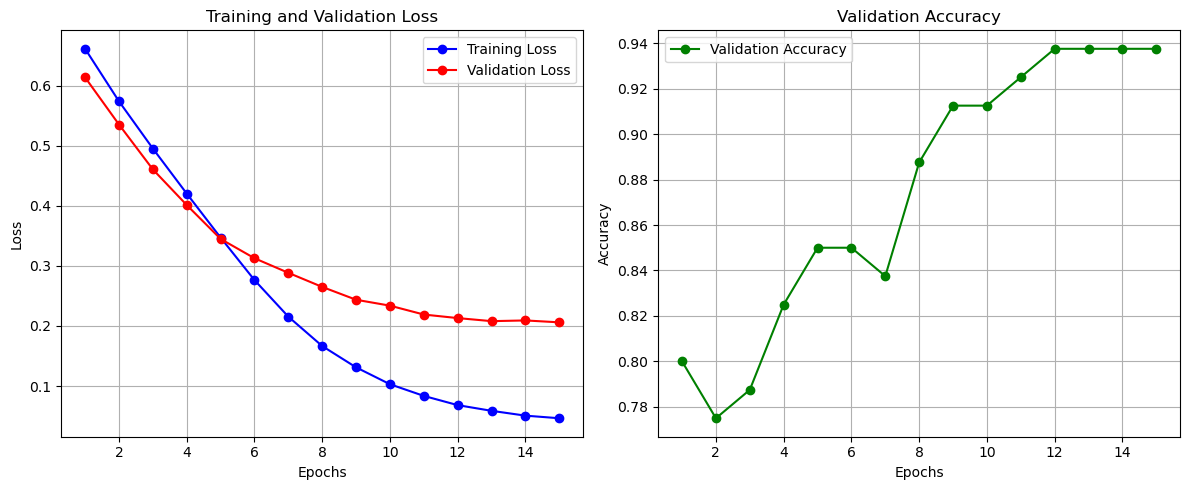

In [ ]:
from matplotlib import pyplot as plt
def plot_training_history(train_loss, val_loss, val_accuracy):
    epochs_range = range(1, len(train_loss) + 1)

    plt.figure(figsize=(12, 5))

    # Plot 1: Loss vs. Epochs
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_loss, 'b-o', label='Training Loss')
    plt.plot(epochs_range, val_loss, 'r-o', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot 2: Accuracy vs. Epochs
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, val_accuracy, 'g-o', label='Validation Accuracy')
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Call the function with your history lists
plot_training_history(train_loss_history, val_loss_history, val_accuracy_history)

In [ ]:
test_acc = get_model_accuracy(he_model, test_loader, device)  # Limit to 10 batches for quick check
print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.9220


In [46]:
question_sample_9th="הראל בעל חנות בגדים. הוא מוכר כל שבוע 200 זוגות מכנסיים ב36 ש״ח. מחקר שביצע גילה שבכל העלאת מחיר של שני ש״ח, הוא ימכור חמישה זוגות פחות. מה המחיר בו ההכנסות מהמכירות יהיו מירביות?" 
question_sample_8th = "בחדר יש פי 3 גברים מנשים. אם ייצאו מהחדר 10 גברים ו2 נשים יהיו בחדר מספר שווה של גברים ונשים. כמה גברים וכמה נשים יש בחדר עכשיו?"

In [48]:
# Evaluate classification for the two sample questions
def classify_and_print(questions):
    he_model.eval()
    he_model.classification_head = he_model.classification_head.to(device)
    with torch.no_grad():
        enc = tokenizer(questions, return_tensors="pt", padding=True, truncation=True)
        input_ids = enc["input_ids"].to(device)
        attention_mask = enc.get("attention_mask", torch.ones_like(input_ids)).to(device)

        outputs = he_model(input_ids, attention_mask=attention_mask, output_hidden_states=True)
        last_hidden = outputs.hidden_states[-1]

        last_token_idx = attention_mask.sum(dim=1) - 1
        batch_idx = torch.arange(last_hidden.size(0), device=device)
        sentence_vecs = last_hidden[batch_idx, last_token_idx]

        logits = he_model.classification_head(sentence_vecs)
        probs = torch.softmax(logits, dim=-1)
        preds = probs.argmax(dim=-1)

        for i, q in enumerate(questions):
            print("Question:")
            print(q)
            print("Predicted label:", int(preds[i].item()), f"(confidence {float(probs[i].max().item()):.4f})")


# Use the sample variables already defined in the notebook
classify_and_print([question_sample_8th, question_sample_9th])

Question:
בחדר יש פי 3 גברים מנשים. אם ייצאו מהחדר 10 גברים ו2 נשים יהיו בחדר מספר שווה של גברים ונשים. כמה גברים וכמה נשים יש בחדר עכשיו?
Predicted label: 0 (confidence 0.9997)
Question:
הראל בעל חנות בגדים. הוא מוכר כל שבוע 200 זוגות מכנסיים ב36 ש״ח. מחקר שביצע גילה שבכל העלאת מחיר של שני ש״ח, הוא ימכור חמישה זוגות פחות. מה המחיר בו ההכנסות מהמכירות יהיו מירביות?
Predicted label: 1 (confidence 0.9690)


That's correct!